Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



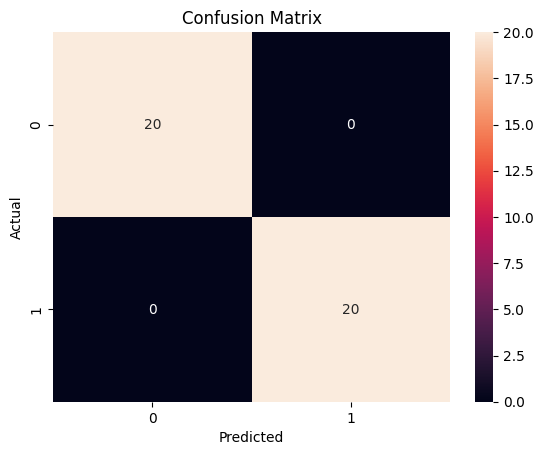

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.2252067726250016e-12
            Iterations: 42
            Function evaluations: 42
            Gradient evaluations: 42
                           Logit Regression Results                           
Dep. Variable:      coverage_category   No. Observations:                  157
Model:                          Logit   Df Residuals:                      135
Method:                           MLE   Df Model:                           21
Date:                Sun, 15 Feb 2026   Pseudo R-squ.:                   1.000
Time:                        20:23:29   Log-Likelihood:            -1.9236e-10
converged:                       True   LL-Null:                       -108.82
Covariance Type:            nonrobust   LLR p-value:                 1.184e-34
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarni

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

file_path = "/Users/gabriel/Desktop/marcy/CID_Food_Access/data/clean/unified_dataset_for_modeling.csv"
df = pd.read_csv(file_path)

if "coverage_ratio" not in df.columns:
    raise ValueError("coverage_ratio column is required before modeling.")

threshold = df["coverage_ratio"].median()
df["coverage_category"] = (df["coverage_ratio"] >= threshold).astype(int)

X = df.drop(columns=["coverage_ratio", "coverage_category"])
X = X.select_dtypes(include=[np.number])
y = df["coverage_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=y_train.index)
X_train_df = X_train_df.loc[:, X_train_df.nunique() > 1]

corr_matrix = X_train_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > 0.999)]
X_train_df = X_train_df.drop(columns=drop_cols)

X_train_sm = sm.add_constant(X_train_df, has_constant="add")

try:
    result = sm.Logit(y_train.loc[X_train_sm.index], X_train_sm).fit(disp=False)
except np.linalg.LinAlgError:
    result = sm.Logit(y_train.loc[X_train_sm.index], X_train_sm).fit_regularized()

print(result.summary())
